# IoT Anomaly Detection: Logistic Regression vs Neural Network Comparison

## Objective
Compare 2 machine learning models for IoT sensor anomaly detection:
- **Logistic Regression** (lightweight, fast edge inference)
- **Neural Network (TensorFlow/Keras)** (heavyweight, higher accuracy)

### Dataset
- **Source**: iot_lab_dataset.csv
- **Features**: Temperature (t), Humidity (h), Acceleration (a)
- **Target**: anomaly_label (NORMAL / ANOMALY)

In [13]:
# ==================== Import Required Libraries ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score,
    roc_auc_score, roc_curve,
    precision_score, confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow.keras import layers, models

warnings.filterwarnings('ignore')
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [15]:
# ==================== Training Helper Functions ====================
def ensure_logistic_trained():
    global lr_model, lr_train_acc_history, lr_val_acc_history, lr_infer, y_pred_lr, y_prob_lr

    if all(name in globals() for name in ['lr_train_acc_history', 'lr_val_acc_history']):
        return

    if not all(name in globals() for name in ['X_train_scaled', 'y_train', 'X_test_scaled', 'y_test']):
        raise NameError(
            "X_train_scaled, y_train, X_test_scaled, and y_test must be defined. "
            "Please run the Data Preprocessing cell before this cell."
        )

    print("📌 Training Logistic Regression automatically...")
    lr_model = LogisticRegression(
        solver='saga',
        max_iter=1,
        warm_start=True,
        random_state=42,
        C=1.0,
        penalty='l2',
        tol=1e-6
    )

    lr_train_acc_history = []
    lr_val_acc_history = []
    epochs = 30

    for epoch in range(epochs):
        lr_model.fit(X_train_scaled, y_train)
        y_train_pred = lr_model.predict(X_train_scaled)
        y_val_pred = lr_model.predict(X_test_scaled)
        lr_train_acc_history.append(accuracy_score(y_train, y_train_pred))
        lr_val_acc_history.append(accuracy_score(y_test, y_val_pred))

    start = time.perf_counter()
    for x in X_test_scaled:
        lr_model.predict([x])
    end = time.perf_counter()
    lr_infer = (end - start) / len(X_test_scaled) * 1000

    y_pred_lr = lr_model.predict(X_test_scaled)
    y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

    print("✅ Logistic Regression trained")
    print(f"⏱️  Inference Time: {lr_infer:.4f} ms/sample")


def ensure_nn_trained():
    global nn_model, history, nn_infer, y_prob_nn, y_pred_nn

    if 'history' in globals():
        return

    if not all(name in globals() for name in ['X_train_scaled', 'y_train', 'X_test_scaled', 'y_test']):
        raise NameError(
            "X_train_scaled, y_train, X_test_scaled, and y_test must be defined. "
            "Please run the Data Preprocessing cell before this cell."
        )

    print("📌 Training Neural Network automatically...")
    nn_model = models.Sequential([
        layers.Input(shape=(3,)),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(16, activation='relu'),
        layers.Dense(8, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    nn_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = nn_model.fit(
        X_train_scaled, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.1,
        class_weight={0: 1.0, 1: 1.5},
        callbacks=[early_stop],
        verbose=0
    )

    start = time.perf_counter()
    _ = nn_model.predict(X_test_scaled, verbose=0)
    end = time.perf_counter()
    nn_infer = (end - start) / len(X_test_scaled) * 1000

    y_prob_nn = nn_model.predict(X_test_scaled, verbose=0).flatten()
    y_pred_nn = (y_prob_nn > 0.3).astype(int)

    print(f"✅ Neural Network trained ({len(history.history['loss'])} epochs)")
    print(f"⏱️  Inference Time: {nn_infer:.4f} ms/sample")

In [16]:
# ==================== Load IoT Dataset ====================
DATASET_PATH = "iot_lab_dataset.csv"
df = pd.read_csv(DATASET_PATH)
df.columns = ["t", "h", "a", "anomaly_label"]
df["anomaly_label"] = df["anomaly_label"].map({"NORMAL": 0, "ANOMALY": 1})

print("✅ Dataset Loaded")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nLabel Distribution:")
print(df['anomaly_label'].value_counts())

✅ Dataset Loaded
Shape: (20000, 4)

First 5 rows:
           t          h         a  anomaly_label
0  22.299665  78.326135  0.000000              0
1  29.969109  67.592632  0.034463              0
2  34.253191  68.439111  0.004742              0
3  24.242657  14.745265  0.737488              1
4  23.750601  72.945461  1.053781              0

Label Distribution:
anomaly_label
0    13628
1     6372
Name: count, dtype: int64


In [3]:
# ==================== Data Preprocessing ====================
X = df[["t", "h", "a"]].values
y = df["anomaly_label"].values

np.random.seed(42)
noise = np.random.normal(0, 0.02, X.shape)
X = X + noise

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data preprocessing done")
print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

✅ Data preprocessing done
Train set: 16000 samples
Test set: 4000 samples


In [26]:
# ==================== Train Logistic Regression ====================
print("🚀 Training Logistic Regression...")

if not all(name in globals() for name in ['X_train_scaled', 'y_train', 'X_test_scaled', 'y_test']):
    raise NameError(
        "X_train_scaled, y_train, X_test_scaled, and y_test must be defined. "
        "Please run the Data Preprocessing cell before this cell."
    )

lr_model = LogisticRegression(
    solver='saga',
    max_iter=1,
    warm_start=True,
    random_state=42,
    C=1.0,
    penalty='l2',
    tol=1e-6
)

lr_train_acc_history = []
lr_val_acc_history = []
epochs = 30

for epoch in range(epochs):
    lr_model.fit(X_train_scaled, y_train)
    y_train_pred = lr_model.predict(X_train_scaled)
    y_val_pred = lr_model.predict(X_test_scaled)
    lr_train_acc_history.append(accuracy_score(y_train, y_train_pred))
    lr_val_acc_history.append(accuracy_score(y_test, y_val_pred))

start = time.perf_counter()
for x in X_test_scaled:
    lr_model.predict([x])
end = time.perf_counter()
lr_infer = (end - start) / len(X_test_scaled) * 1000

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print(f"✅ Logistic Regression trained")
print(f"⏱️  Inference Time: {lr_infer:.4f} ms/sample")

🚀 Training Logistic Regression...
✅ Logistic Regression trained
⏱️  Inference Time: 0.0518 ms/sample


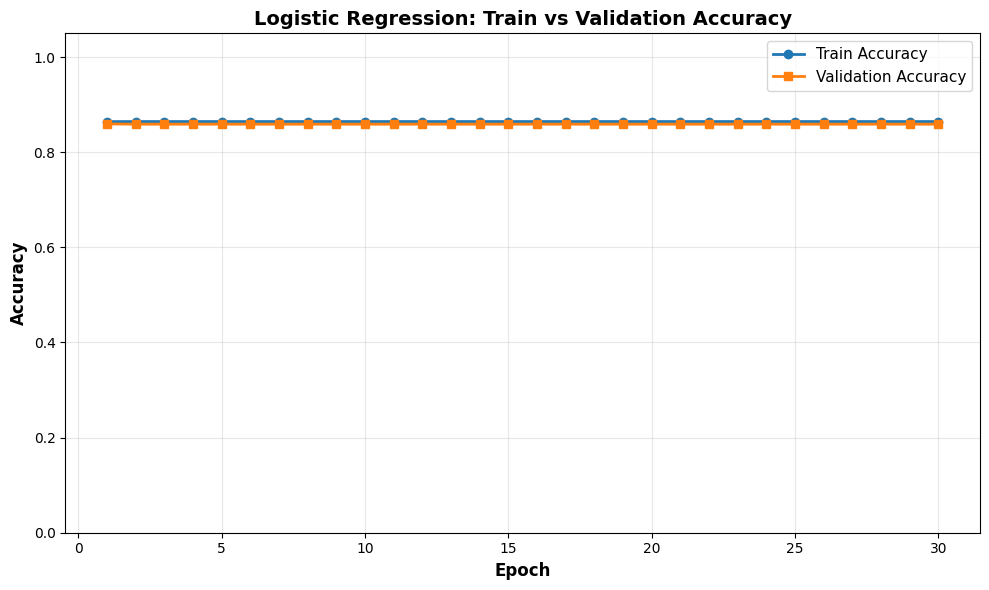

✅ Logistic Regression accuracy curve saved


In [27]:
# ==================== Logistic Regression Accuracy Curve ====================
ensure_logistic_trained()

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(lr_train_acc_history) + 1), lr_train_acc_history,
         marker='o', linewidth=2, label='Train Accuracy', color='#1f77b4')
plt.plot(range(1, len(lr_val_acc_history) + 1), lr_val_acc_history,
         marker='s', linewidth=2, label='Validation Accuracy', color='#ff7f0e')

plt.title('Logistic Regression: Train vs Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.ylim([0.0, 1.05])
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('lr_accuracy_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Logistic Regression accuracy curve saved')

In [22]:
# ==================== Train Neural Network ====================
print("🚀 Building and training Neural Network...")

# Ensure preprocessing variables exist; if not, create them from df
if not all(name in globals() for name in ['X_train_scaled', 'y_train', 'X_test_scaled', 'y_test']):
    if 'df' not in globals():
        raise NameError("df not found. Run the dataset loading cell before this one.")
    X = df[["t", "h", "a"]].values
    y = df["anomaly_label"].values

    np.random.seed(42)
    noise = np.random.normal(0, 0.02, X.shape)
    X = X + noise

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print("✅ Data preprocessing performed inside training cell")

# If already trained (history exists), skip retraining
if 'history' in globals():
    print(f"✅ Neural Network already trained ({len(history.history.get('loss', []))} epochs). Skipping training.")
else:
    nn_model = models.Sequential([
        layers.Input(shape=(3,)),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(16, activation='relu'),
        layers.Dense(8, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    nn_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = nn_model.fit(
        X_train_scaled, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.1,
        class_weight={0: 1.0, 1: 1.5},
        callbacks=[early_stop],
        verbose=0
    )

    start = time.perf_counter()
    _ = nn_model.predict(X_test_scaled, verbose=0)
    end = time.perf_counter()
    nn_infer = (end - start) / len(X_test_scaled) * 1000

    y_prob_nn = nn_model.predict(X_test_scaled, verbose=0).flatten()
    y_pred_nn = (y_prob_nn > 0.3).astype(int)

    print(f"✅ Neural Network trained ({len(history.history['loss'])} epochs)")
    print(f"⏱️  Inference Time: {nn_infer:.4f} ms/sample")

🚀 Building and training Neural Network...
✅ Data preprocessing performed inside training cell
✅ Neural Network trained (24 epochs)
⏱️  Inference Time: 0.0463 ms/sample


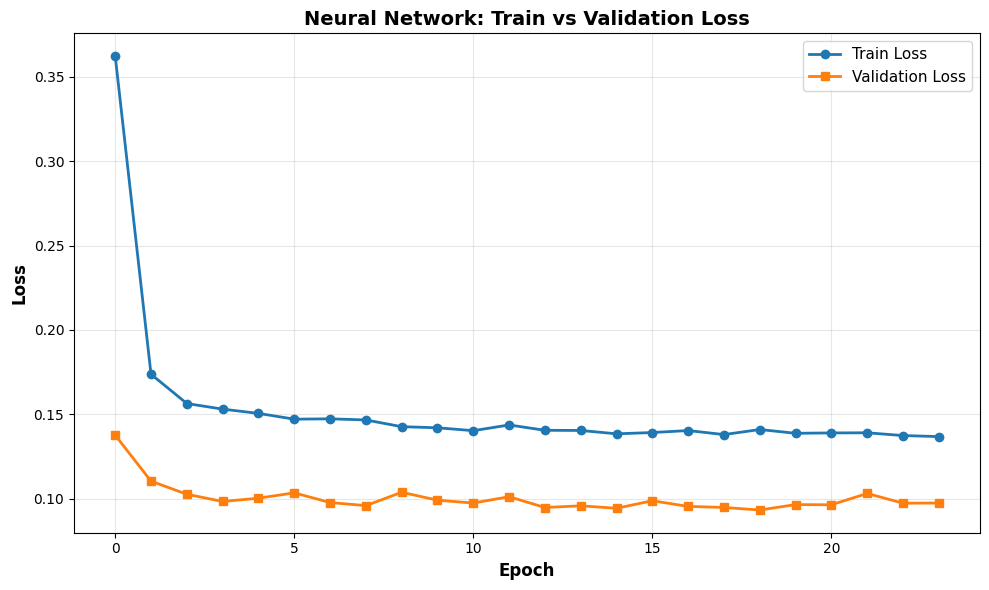

✅ Neural Network loss curve saved


In [23]:
# ==================== Neural Network Loss Curve ====================

if 'history' not in globals():
    print("📌 Training Neural Network automatically...")
    nn_model = models.Sequential([
        layers.Input(shape=(3,)),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(16, activation='relu'),
        layers.Dense(8, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    nn_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = nn_model.fit(
        X_train_scaled, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.1,
        class_weight={0: 1.0, 1: 1.5},
        callbacks=[early_stop],
        verbose=0
    )

    start = time.perf_counter()
    _ = nn_model.predict(X_test_scaled, verbose=0)
    end = time.perf_counter()
    nn_infer = (end - start) / len(X_test_scaled) * 1000

    y_prob_nn = nn_model.predict(X_test_scaled, verbose=0).flatten()
    y_pred_nn = (y_prob_nn > 0.3).astype(int)

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], marker='o', linewidth=2,
         label='Train Loss', color='#1f77b4')
plt.plot(history.history['val_loss'], marker='s', linewidth=2,
         label='Validation Loss', color='#ff7f0e')

plt.title('Neural Network: Train vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Loss', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('nn_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Neural Network loss curve saved')

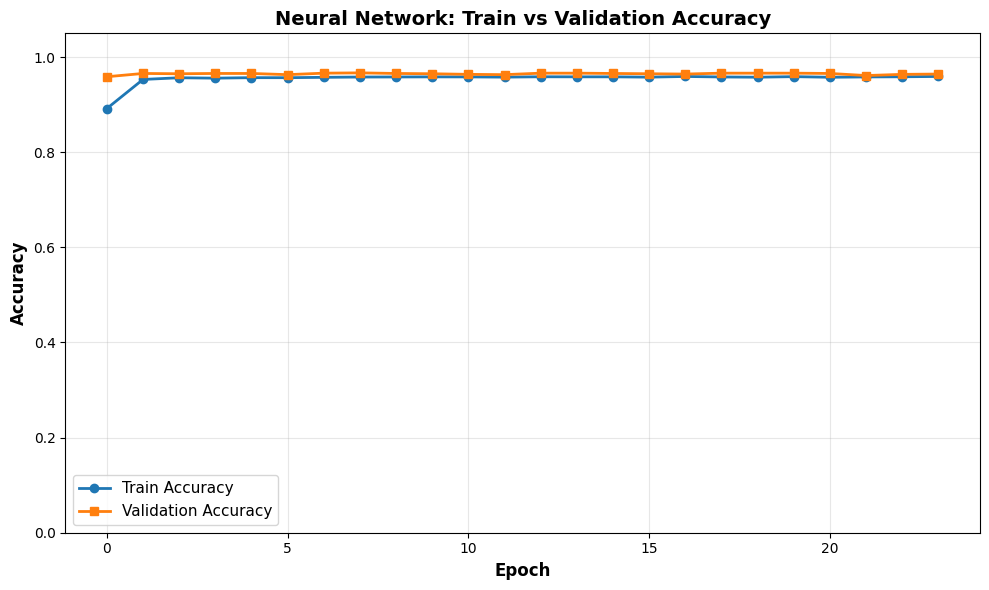

✅ Neural Network accuracy curve saved


In [25]:
# ==================== Neural Network Accuracy Curve ====================

if 'history' not in globals():
    print("📌 Training Neural Network automatically...")
    nn_model = models.Sequential([
        layers.Input(shape=(3,)),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(16, activation='relu'),
        layers.Dense(8, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    nn_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = nn_model.fit(
        X_train_scaled, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.1,
        class_weight={0: 1.0, 1: 1.5},
        callbacks=[early_stop],
        verbose=0
    )

    start = time.perf_counter()
    _ = nn_model.predict(X_test_scaled, verbose=0)
    end = time.perf_counter()
    nn_infer = (end - start) / len(X_test_scaled) * 1000

    y_prob_nn = nn_model.predict(X_test_scaled, verbose=0).flatten()
    y_pred_nn = (y_prob_nn > 0.3).astype(int)

plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], marker='o', linewidth=2,
         label='Train Accuracy', color='#1f77b4')
plt.plot(history.history['val_accuracy'], marker='s', linewidth=2,
         label='Validation Accuracy', color='#ff7f0e')

plt.title('Neural Network: Train vs Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.ylim([0.0, 1.05])
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('nn_accuracy_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Neural Network accuracy curve saved')

In [6]:
# ==================== Calculate Metrics ====================
lr_acc = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, zero_division=0)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)
lr_cm = confusion_matrix(y_test, y_pred_lr)

nn_acc = accuracy_score(y_test, y_pred_nn)
nn_precision = precision_score(y_test, y_pred_nn, zero_division=0)
nn_recall = recall_score(y_test, y_pred_nn)
nn_f1 = f1_score(y_test, y_pred_nn)
nn_auc = roc_auc_score(y_test, y_prob_nn)
nn_cm = confusion_matrix(y_test, y_pred_nn)

print("=" * 70)
print("🔵 LOGISTIC REGRESSION METRICS")
print("=" * 70)
print(f"Accuracy:  {lr_acc:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")
print(f"ROC-AUC:   {lr_auc:.4f}")

print("\n" + "=" * 70)
print("🔴 NEURAL NETWORK METRICS")
print("=" * 70)
print(f"Accuracy:  {nn_acc:.4f}")
print(f"Precision: {nn_precision:.4f}")
print(f"Recall:    {nn_recall:.4f}")
print(f"F1-Score:  {nn_f1:.4f}")
print(f"ROC-AUC:   {nn_auc:.4f}")

🔵 LOGISTIC REGRESSION METRICS
Accuracy:  0.8167
Precision: 0.8394
Recall:    0.5933
F1-Score:  0.6952
ROC-AUC:   0.7549

🔴 NEURAL NETWORK METRICS
Accuracy:  0.8738
Precision: 0.7958
Recall:    0.8630
F1-Score:  0.8281
ROC-AUC:   0.9551


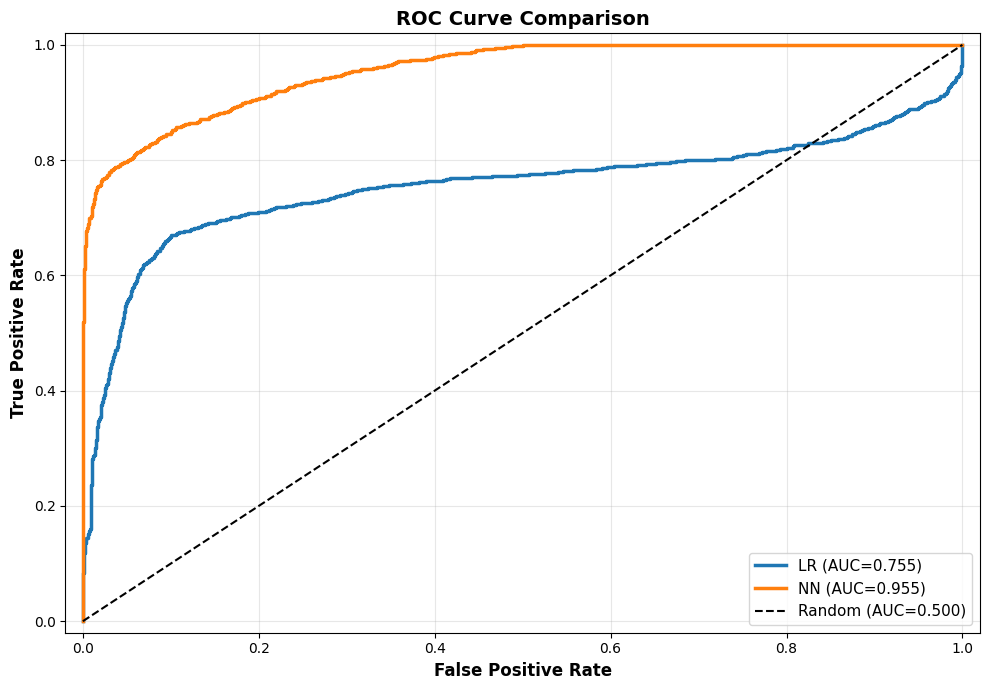

✅ ROC Curve saved


In [7]:
# ==================== ROC Curve ====================
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)

plt.figure(figsize=(10, 7))
plt.plot(fpr_lr, tpr_lr, linewidth=2.5, label=f"LR (AUC={lr_auc:.3f})", color='#1f77b4')
plt.plot(fpr_nn, tpr_nn, linewidth=2.5, label=f"NN (AUC={nn_auc:.3f})", color='#ff7f0e')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random (AUC=0.500)')
plt.xlabel("False Positive Rate", fontsize=12, fontweight='bold')
plt.ylabel("True Positive Rate", fontsize=12, fontweight='bold')
plt.title("ROC Curve Comparison", fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.tight_layout()
plt.savefig("roc_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ ROC Curve saved")

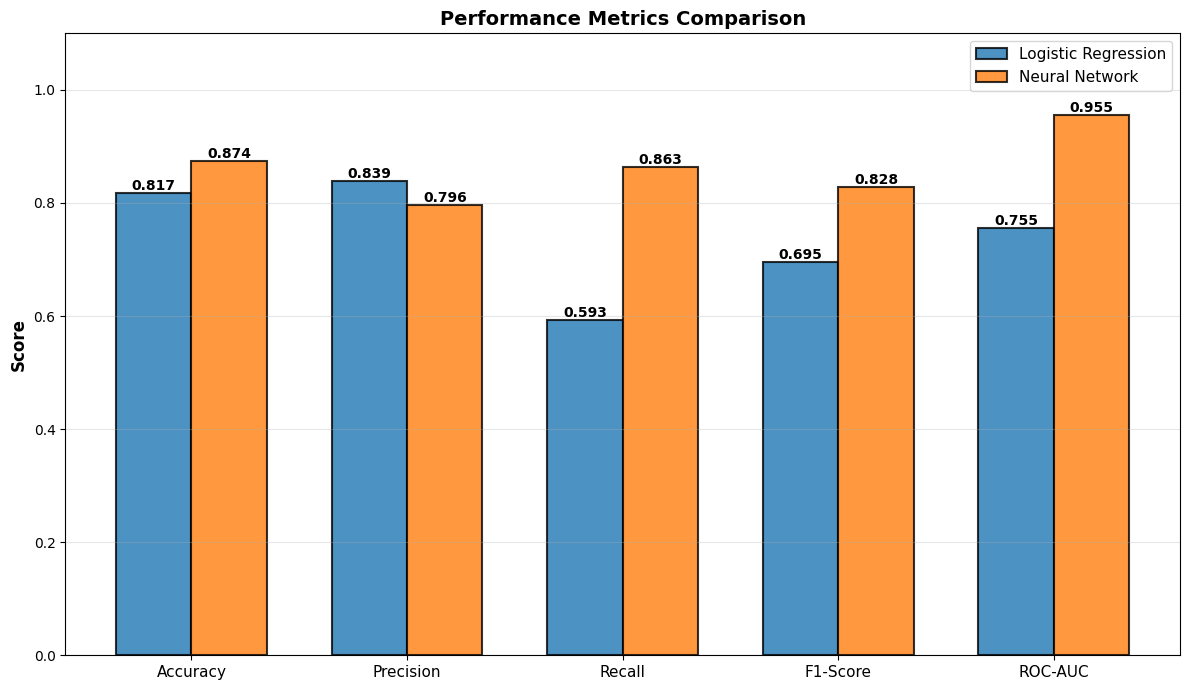

✅ Metrics comparison saved


In [8]:
# ==================== Metrics Comparison Bar Chart ====================
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
lr_metrics = [lr_acc, lr_precision, lr_recall, lr_f1, lr_auc]
nn_metrics = [nn_acc, nn_precision, nn_recall, nn_f1, nn_auc]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
bars1 = ax.bar(x - width/2, lr_metrics, width, label='Logistic Regression', 
               color='#1f77b4', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, nn_metrics, width, label='Neural Network', 
               color='#ff7f0e', alpha=0.8, edgecolor='black', linewidth=1.5)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Performance Metrics Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim([0, 1.1])
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("metrics_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Metrics comparison saved")

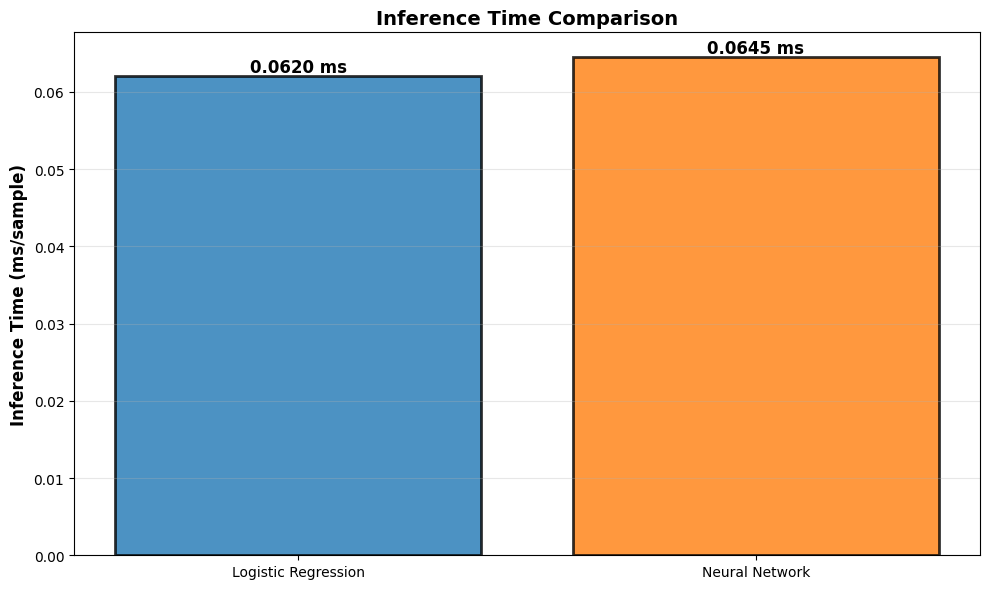

✅ Inference time comparison saved


In [9]:
# ==================== Inference Time Comparison ====================
fig, ax = plt.subplots(figsize=(10, 6))
models = ['Logistic Regression', 'Neural Network']
infer_times = [lr_infer, nn_infer]
colors = ['#1f77b4', '#ff7f0e']

bars = ax.bar(models, infer_times, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f} ms', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Inference Time (ms/sample)', fontsize=12, fontweight='bold')
ax.set_title('Inference Time Comparison', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("inference_time_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Inference time comparison saved")


===== CONFUSION MATRIX DETAILS =====

[Logistic Regression]
TP: 836 | TN: 2431 | FP: 160 | FN: 573

[Neural Network]
TP: 1216 | TN: 2279 | FP: 312 | FN: 193


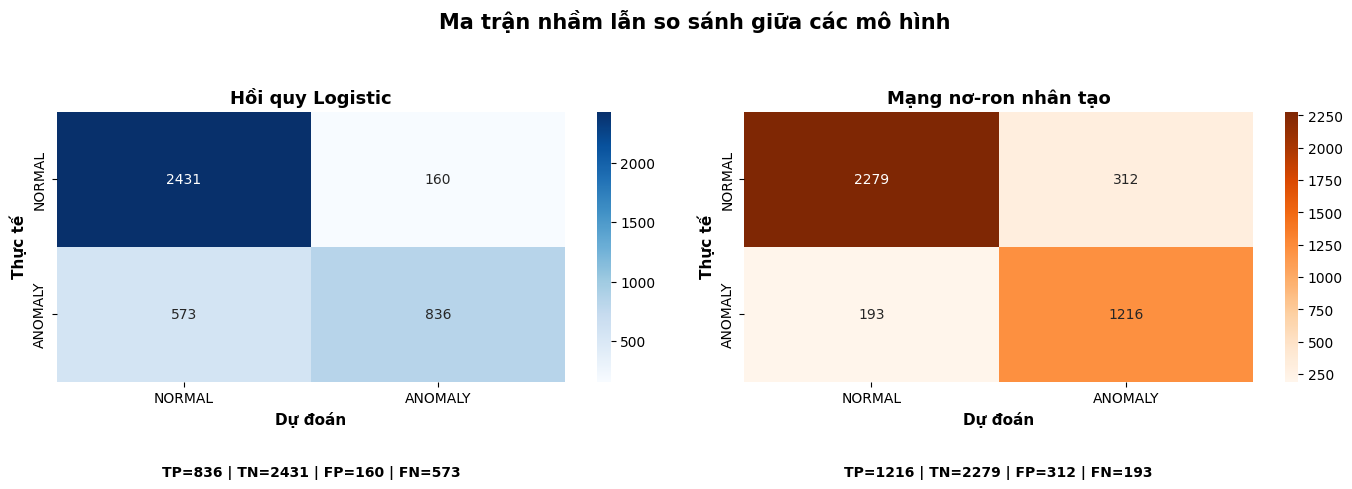


✅ Confusion matrices saved as: confusion_matrices.png


In [15]:
# ==================== Confusion Matrix + TP/TN/FP/FN ====================

import seaborn as sns
import matplotlib.pyplot as plt

def extract_metrics(cm):
    TN, FP, FN, TP = cm.ravel()
    return TN, FP, FN, TP

# ==================== Extract values ====================
lr_TN, lr_FP, lr_FN, lr_TP = extract_metrics(lr_cm)
nn_TN, nn_FP, nn_FN, nn_TP = extract_metrics(nn_cm)

print("\n===== CONFUSION MATRIX DETAILS =====")

print("\n[Logistic Regression]")
print(f"TP: {lr_TP} | TN: {lr_TN} | FP: {lr_FP} | FN: {lr_FN}")

print("\n[Neural Network]")
print(f"TP: {nn_TP} | TN: {nn_TN} | FP: {nn_FP} | FN: {nn_FN}")

# ==================== Plot ====================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------- Logistic Regression ----------
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=axes[0],
            xticklabels=['NORMAL', 'ANOMALY'],
            yticklabels=['NORMAL', 'ANOMALY'])

axes[0].set_title('Hồi quy Logistic', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Dự đoán', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Thực tế', fontsize=11, fontweight='bold')

axes[0].text(0.5, -0.35,
             f"TP={lr_TP} | TN={lr_TN} | FP={lr_FP} | FN={lr_FN}",
             ha='center',
             transform=axes[0].transAxes,
             fontsize=10,
             fontweight='bold',
             color='black')

# ---------- Neural Network ----------
sns.heatmap(nn_cm, annot=True, fmt='d', cmap='Oranges', cbar=True, ax=axes[1],
            xticklabels=['NORMAL', 'ANOMALY'],
            yticklabels=['NORMAL', 'ANOMALY'])

axes[1].set_title('Mạng nơ-ron nhân tạo', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Dự đoán', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Thực tế', fontsize=11, fontweight='bold')

axes[1].text(0.5, -0.35,
             f"TP={nn_TP} | TN={nn_TN} | FP={nn_FP} | FN={nn_FN}",
             ha='center',
             transform=axes[1].transAxes,
             fontsize=10,
             fontweight='bold',
             color='black')

# ==================== Title ====================
fig.suptitle('Ma trận nhầm lẫn so sánh giữa các mô hình',
             fontsize=15,
             fontweight='bold',
             y=1.05)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Confusion matrices saved as: confusion_matrices.png")

In [11]:
# ==================== Classification Report ====================
print("\n" + "=" * 70)
print("📊 CLASSIFICATION REPORT (Neural Network Model)")
print("=" * 70)
print(classification_report(y_test, y_pred_nn, 
                          target_names=['NORMAL', 'ANOMALY'],
                          digits=4))


📊 CLASSIFICATION REPORT (Neural Network Model)
              precision    recall  f1-score   support

      NORMAL     0.9219    0.8796    0.9003      2591
     ANOMALY     0.7958    0.8630    0.8281      1409

    accuracy                         0.8738      4000
   macro avg     0.8589    0.8713    0.8642      4000
weighted avg     0.8775    0.8738    0.8748      4000



In [12]:
# ==================== Sanity Check ====================
print("\n🧪 SANITY CHECK - Neural Network Edge Case Testing")
test_cases = [
    ("NORMAL          ", [30, 60, 0.1]),
    ("HIGH TEMP       ", [40, 60, 0.1]),
    ("LOW HUMIDITY    ", [30, 10, 0.1]),
    ("ACCEL SPIKE     ", [30, 60, 3.0]),
]

print(f"\n{'Case':<20} {'t':<6} {'h':<6} {'a':<8} {'Probability':<15} {'Prediction'}")
print("-" * 75)

for name, sample in test_cases:
    sample_scaled = scaler.transform([sample])
    prob = nn_model.predict(sample_scaled, verbose=0)[0][0]
    prediction = "ANOMALY" if prob > 0.3 else "NORMAL"
    print(f"{name:<20} {sample[0]:<6} {sample[1]:<6} {sample[2]:<8.1f} {prob:<15.4f} {prediction}")


🧪 SANITY CHECK - Neural Network Edge Case Testing

Case                 t      h      a        Probability     Prediction
---------------------------------------------------------------------------
NORMAL               30     60     0.1      0.0087          NORMAL
HIGH TEMP            40     60     0.1      0.9977          ANOMALY
LOW HUMIDITY         30     10     0.1      0.9994          ANOMALY
ACCEL SPIKE          30     60     3.0      0.9697          ANOMALY


In [13]:
# ==================== Summary Table ====================
summary_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Neural Network'],
    'Accuracy': [lr_acc, nn_acc],
    'Precision': [lr_precision, nn_precision],
    'Recall': [lr_recall, nn_recall],
    'F1-Score': [lr_f1, nn_f1],
    'ROC-AUC': [lr_auc, nn_auc],
    'Inference_time_ms': [lr_infer, nn_infer]
})

print("\n" + "=" * 100)
print("📋 MODEL COMPARISON SUMMARY TABLE")
print("=" * 100)
print(summary_df.round(4).to_string(index=False))
print("=" * 100)


📋 MODEL COMPARISON SUMMARY TABLE
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Inference_time_ms
Logistic Regression    0.8168     0.8394  0.5933    0.6952   0.7549             0.0620
     Neural Network    0.8738     0.7958  0.8630    0.8281   0.9551             0.0645


In [14]:
# ==================== Save Models ====================
print("\n" + "=" * 70)
print("💾 SAVING MODELS")
print("=" * 70)

nn_model.save("model_nn.keras")
print("✅ Keras model saved: model_nn.keras")

converter = tf.lite.TFLiteConverter.from_keras_model(nn_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open("model_nn.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ TFLite model exported: model_nn.tflite")

keras_size = os.path.getsize("model_nn.keras") / 1024
tflite_size = os.path.getsize("model_nn.tflite") / 1024

print(f"\n📊 MODEL FILE SIZES:")
print(f"  Keras (.keras):     {keras_size:.2f} KB")
print(f"  TFLite (.tflite):   {tflite_size:.2f} KB")
print(f"  Compression Ratio:  {keras_size/tflite_size:.2f}x smaller")
print(f"\n✅ ALL MODELS SAVED SUCCESSFULLY!")


💾 SAVING MODELS
✅ Keras model saved: model_nn.keras
INFO:tensorflow:Assets written to: C:\Users\HOANGANH\AppData\Local\Temp\tmp42ey56c_\assets


INFO:tensorflow:Assets written to: C:\Users\HOANGANH\AppData\Local\Temp\tmp42ey56c_\assets


Saved artifact at 'C:\Users\HOANGANH\AppData\Local\Temp\tmp42ey56c_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2760808378256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2760808379024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2760808381904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2760808382288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2760808380944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2760808377872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2760808380560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2760808381136: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ TFLite model exported: model_nn.tflite

📊 MODEL FILE SIZES:
  Keras (.keras):     41.18 KB
  TFLite (.tflite):   5.66 KB
  Compression Ratio:  7.28x